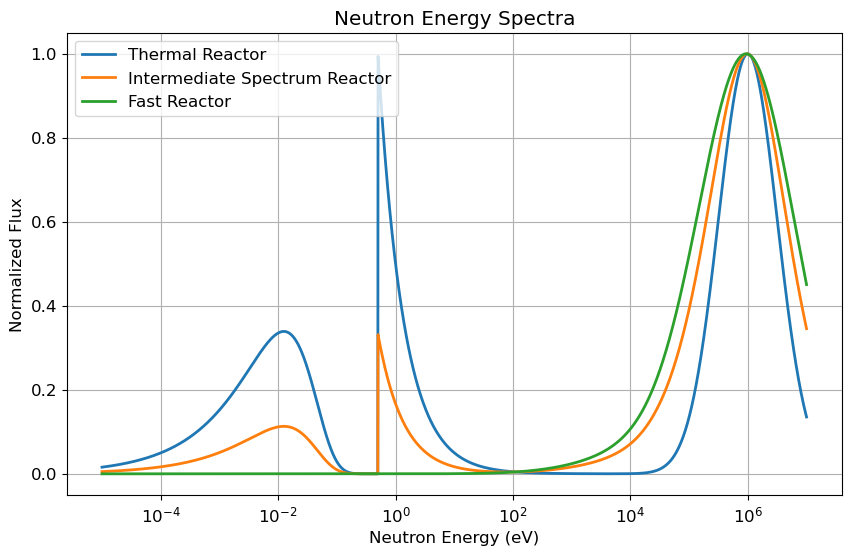

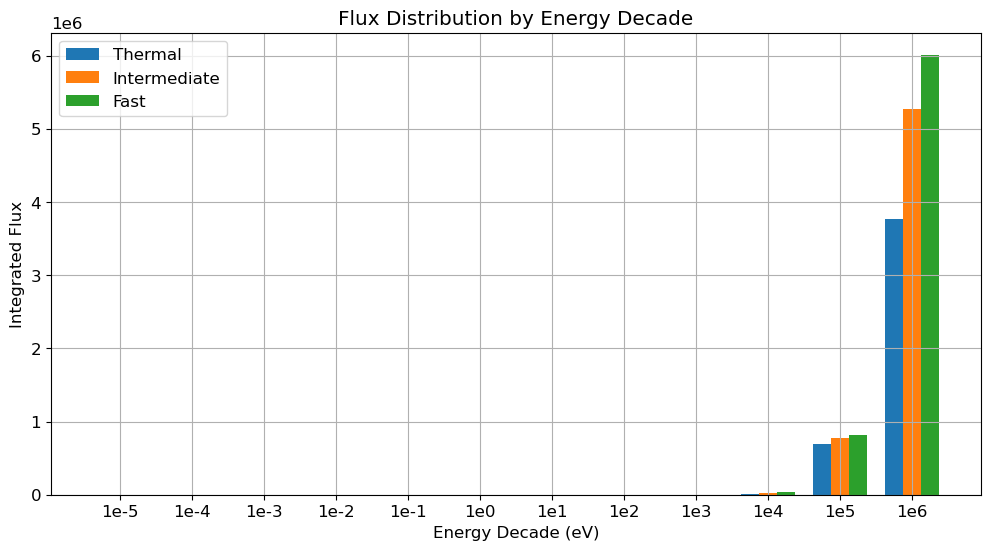

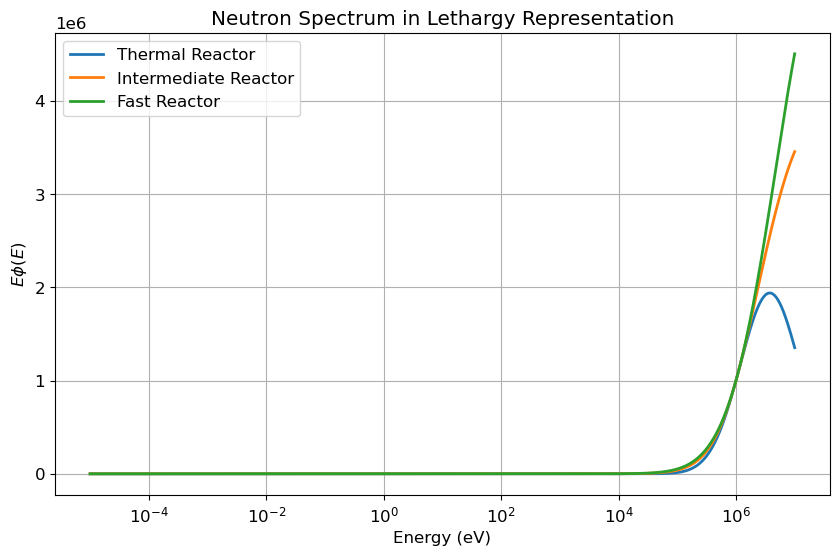

In [2]:
# Neutron Energy Spectrum Analysis in Nuclear Reactors

## Introduction

# The neutron energy spectrum is one of the most important quantities in reactor physics.

# Different nuclear reactors operate with different neutron energy distributions:

# - Thermal reactors contain mostly low-energy neutrons.
# - Fast reactors contain mostly high-energy neutrons.
# - Intermediate-spectrum reactors exhibit characteristics of both.

# The neutron spectrum strongly affects:

# - Fission probability
# - Capture probability
# - Fuel utilization
# - Reactor criticality
# - Breeding performance
# - Shielding requirements

# In this notebook we construct simplified neutron energy spectra for:

# 1. Thermal Reactor
# 2. Fast Reactor
# 3. Intermediate Spectrum Reactor

# and compare their behavior using Python visualization tools.

#This notebook is intended for educational purposes and does 
# not replace detailed transport calculations performed with
# codes such as OpenMC, MCNP, Serpent, SCALE, or DRAGON.

## Physical Background

# Neutron energies span many orders of magnitude:

# | Region | Typical Energy |
# |----------|----------|
# | Thermal | ~0.025 eV |
# | Epithermal | 1 eV – 100 keV |
# | Fast | >100 keV |

# A typical thermal reactor spectrum contains:

# - Maxwell-Boltzmann thermal peak
# - Epithermal slowing-down region
# - Fast fission component

# A fast reactor spectrum lacks the thermal peak 
# and remains concentrated at high energies.

# The neutron spectrum is commonly plotted on 
# logarithmic energy scales because neutron 
# energies span more than ten orders of magnitude.

import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["font.size"] = 12

## Energy Grid

# We create a logarithmically spaced energy grid from:

# - 10⁻⁵ eV
# - to 10⁷ eV (10 MeV)

# covering thermal, epithermal and fast regions.

E = np.logspace(-5, 7, 3000)  # eV

## Thermal Reactor Spectrum

# A simplified thermal spectrum consists of:

# 1. Maxwellian thermal peak
# 2. Epithermal 1/E region
# 3. Fast fission tail

thermal_peak = (
    np.sqrt(E)
    * np.exp(-E/0.025)
)

epithermal = np.where(
    (E > 0.5) & (E < 1e5),
    1/E,
    0
)

fast_tail = np.exp(
    -((np.log10(E)-6)**2)/(2*0.5**2)
)

thermal_spectrum = (
    5*thermal_peak
    + 0.5*epithermal
    + fast_tail
)

thermal_spectrum /= np.max(thermal_spectrum)

## Fast Reactor Spectrum

# Fast reactors contain very little moderation.

# The neutron population remains concentrated around fission energies.

fast_spectrum = np.exp(
    -((np.log10(E)-6)**2)/(2*0.8**2)
)

fast_spectrum += 0.1*np.exp(
    -((np.log10(E)-5)**2)/(2*1.2**2)
)

fast_spectrum /= np.max(fast_spectrum)

## Intermediate Spectrum Reactor

# This spectrum lies between thermal and fast systems.

intermediate_spectrum = (
    0.4*thermal_spectrum
    + 0.8*fast_spectrum
)

intermediate_spectrum /= np.max(intermediate_spectrum)

## Plot of Neutron Energy Spectra

plt.figure()

plt.semilogx(
    E,
    thermal_spectrum,
    label="Thermal Reactor",
    linewidth=2
)

plt.semilogx(
    E,
    intermediate_spectrum,
    label="Intermediate Spectrum Reactor",
    linewidth=2
)

plt.semilogx(
    E,
    fast_spectrum,
    label="Fast Reactor",
    linewidth=2
)

plt.xlabel("Neutron Energy (eV)")
plt.ylabel("Normalized Flux")
plt.title("Neutron Energy Spectra")
plt.grid(True)
plt.legend()

plt.show()

## Spectrum by Energy Decade

energy_bins = np.logspace(-5, 7, 13)

thermal_hist = []
fast_hist = []
inter_hist = []

for i in range(len(energy_bins)-1):

    mask = (
        (E >= energy_bins[i])
        &
        (E < energy_bins[i+1])
    )

    thermal_hist.append(
        np.trapezoid(
            thermal_spectrum[mask],
            E[mask]
        )
    )

    fast_hist.append(
        np.trapezoid(
            fast_spectrum[mask],
            E[mask]
        )
    )

    inter_hist.append(
        np.trapezoid(
            intermediate_spectrum[mask],
            E[mask]
        )
    )

centers = np.arange(len(thermal_hist))

width = 0.25

plt.figure(figsize=(12,6))

plt.bar(
    centers-width,
    thermal_hist,
    width,
    label="Thermal"
)

plt.bar(
    centers,
    inter_hist,
    width,
    label="Intermediate"
)

plt.bar(
    centers+width,
    fast_hist,
    width,
    label="Fast"
)

labels = [
    f"1e{p}"
    for p in range(-5,7)
]

plt.xticks(centers, labels)

plt.xlabel("Energy Decade (eV)")
plt.ylabel("Integrated Flux")
plt.title("Flux Distribution by Energy Decade")

plt.legend()
plt.grid(True)

plt.show()

## Fraction of Thermal, Epithermal and Fast Neutrons

thermal_region = E < 1.0

epithermal_region = (
    (E >= 1.0)
    &
    (E < 1e5)
)

fast_region = E >= 1e5

def region_fraction(spectrum):

    total = np.trapezoid(
        spectrum,
        E
    )

    thermal = np.trapezoid(
        spectrum[thermal_region],
        E[thermal_region]
    )

    epithermal = np.trapezoid(
        spectrum[epithermal_region],
        E[epithermal_region]
    )

    fast = np.trapezoid(
        spectrum[fast_region],
        E[fast_region]
    )

    return (
        100*thermal/total,
        100*epithermal/total,
        100*fast/total
    )

thermal_frac = region_fraction(thermal_spectrum)
inter_frac = region_fraction(intermediate_spectrum)
fast_frac = region_fraction(fast_spectrum)

import pandas as pd

df = pd.DataFrame(
    {
        "Thermal (%)":[
            thermal_frac[0],
            inter_frac[0],
            fast_frac[0]
        ],
        "Epithermal (%)":[
            thermal_frac[1],
            inter_frac[1],
            fast_frac[1]
        ],
        "Fast (%)":[
            thermal_frac[2],
            inter_frac[2],
            fast_frac[2]
        ]
    },
    index=[
        "Thermal Reactor",
        "Intermediate Reactor",
        "Fast Reactor"
    ]
)

df.round(2)

## Spectrum Comparison in Lethargy Form

# Reactor physicists often examine:

# \[
# E \phi(E)
# \]

# instead of:

# \[
# \phi(E)
# \]

# because equal intervals in logarithmic energy 
# correspond to equal lethargy intervals.

plt.figure()

plt.semilogx(
    E,
    E*thermal_spectrum,
    label="Thermal Reactor",
    linewidth=2
)

plt.semilogx(
    E,
    E*intermediate_spectrum,
    label="Intermediate Reactor",
    linewidth=2
)

plt.semilogx(
    E,
    E*fast_spectrum,
    label="Fast Reactor",
    linewidth=2
)

plt.xlabel("Energy (eV)")
plt.ylabel(r"$E\phi(E)$")

plt.title("Neutron Spectrum in Lethargy Representation")

plt.grid(True)
plt.legend()

plt.show()

## Discussion

# The results illustrate several fundamental reactor physics concepts:

### Thermal Reactor

# - Large thermal neutron population
# - Strong moderation
# - High probability of thermal fission in U-235

### Fast Reactor

# - Most neutrons remain at high energy
# - Minimal moderation
# - Better breeding potential
# - More efficient utilization of U-238

### Intermediate Reactor

# - Mixed characteristics
# - Useful for advanced reactor concepts
# - Can improve transmutation performance

# The neutron energy spectrum is a central quantity in determining:

# - Multiplication factor (k_eff)
# - Reaction rates
# - Fuel burnup
# - Breeding ratio
# - Power distribution
# - Radiation shielding requirements

# Conclusions

# In this notebook we:

# - Constructed simplified neutron spectra
# - Compared thermal, intermediate and fast reactors
# - Analyzed flux distributions over energy
# - Calculated neutron fractions by energy region
# - Visualized spectra in conventional and lethargy representations

# Although highly simplified, the notebook demonstrates the essential 
# physics behind neutron energy distributions in nuclear reactors and 
# provides a useful educational introduction before moving to transport 
# calculations using OpenMC, Serpent, MCNP, or SCALE.